In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# NewAthena 2026 projects w/ Isobel Romero-Shaw and others

Useful information on NewAthena from https://www.eoportal.org/satellite-missions/newathena#h.1fob9te:

- NewAthena carries two instruments, the Wide Field Imager (WFI), an array of silicone active pixel sensors with an integrated detector/amplifier structure, and the X-ray Integral Field Unit (X-IFU), an X-ray spectrometer consisting of a microcalorimeter array.

- WFI has a field of view (FoV) of 40’ x 40’, with a spectral resolution of 170 eV at 6 keV. X-IFU has a spectral resolution of 4 eV, up to 7 keV, over a 4’ equivalent diameter field-of-view (over the hexagonal shape), covered with ~1500 pixels of 5” size.

- Both instruments operate in an energy range between about 0.2 keV and 12.0 keV

- The instruments will be placed in the focal plane of an X-ray telescope enabling an angular resolution of 9” on-axis (Half-Energy Width).

- NewAthena will operate from the First Lagrange point, L1, a gravitationally semi-stable point 1.5 million km from Earth.

**Step 1: Using Blandford-Znajek jet luminosity equation, calculate BBH and AGN parameters required to launch jets visible by NewAthena.**

In [2]:
# Constants:

G = 6.67430e-8               # Gravitatoinal constant (cm^3 g^-1 s^-2)
c = 2.99792458e10            # Speed of light (cm/s)
pi = np.pi                   # Pi
k_B = 1.380649e-16           # Boltzmann constant (erg/K)
m_p = 1.6726219e-24          # Proton mass (g)
M_sun = 1.989e33             # Mass of the Sun (g)
M_AGN = 1e8 * M_sun          # Typical mass of an AGN
R = 1e4                      # Gravitational radii. See https://arxiv.org/abs/1206.2309 for reference
f = 0.1                      # Jet conversion efficiency. See https://arxiv.org/abs/2311.10518 for reference
d_L_Mpc = np.array([100, 500, 1000, 3000])    # Typical distance of AGN from us (Mpc)
Mpc_to_cm = 3.085677581e24   # Conversion of Mpc to cm
d_L = d_L_Mpc * Mpc_to_cm    # Typical distance of AGN from us (cm)



def blanford_znajek(M_binary, rho_AGN, v_k, c_s, f):
    Mdot = (4 * pi * G**2 * M_binary**2 * rho_AGN) / ((v_k**2 + c_s**2)**1.5)
    L_j = f * Mdot * c**2
    
    return L_j


def sound_speed(T, gamma=5/3, mu=0.6):
    return np.sqrt(gamma * k_B * T / (mu * m_p))  # cm/s


def gravitational_radius(M):
    return G * M / c**2  # cm


def orbital_radius(R, M_AGN):
    return R * gravitational_radius(M_AGN)


def keplerian_velocity(M_AGN, r):
    return np.sqrt(G * M_AGN / r)  # cm/s


def xray_flux(L,d):
    return L/(4*np.pi*(d**2))

In [3]:
r = orbital_radius(R, M_AGN)
v_k = keplerian_velocity(M_AGN, r)
print(v_k)

299792458.0


In [16]:
# Establish parameter space (for M_binary, rho_AGN, T (influences c_s))

N = 100 # Use for now, increase for more accuracy, reduce if computations taking too long

M_vals = np.logspace(2, 6, N)  # in solar masses. See arXiv:2406.01687 for reference on values
rho_vals = np.logspace(-14,-10,N) # in units of g/cm^3. See https://arxiv.org/abs/2009.03936 Appendix for reference
T_vals = np.logspace(4,5,N) # See https://arxiv.org/abs/1806.04680 for reference


r = orbital_radius(R, M_AGN)
v_k = keplerian_velocity(M_AGN, r)


results_dict = []
L_j_list = []

for M in M_vals:
    M_cgs = M * M_sun  # This converts the M units from solar masses to grams to stay consistent with CGS units
    for rho in rho_vals:
        for T in T_vals:
            c_s = sound_speed(T)
            L_j = blanford_znajek(M_cgs, rho, v_k, c_s, f)
            #L_Edd = 1.3e38 * M     # M in solar masses
            #L_j = min(L_j, L_Edd)  # Apply luminosity limit to not consider unphysical parameters just in case
            L_j_list.append(L_j)
            results_dict.append({
                "M": M,
                "rho": rho,
                "T": T,
                "L_j": L_j
            })

In [17]:
print(L_j_list[0:20]) # Printing a small sample just to see
print(type(L_j_list))
print("Min L_j:", np.min(L_j_list))
print("Max L_j:", np.max(L_j_list))


# CHECK LUMINOSITY CONSTANTS TO SEE



print(results_dict[0]) # This is a list of dictionaries to see which M, rho and T values give each L_j value

[7.386752628851771e+37, 7.386745977409987e+37, 7.386739169463316e+37, 7.386732201329535e+37, 7.38672506923979e+37, 7.386717769336571e+37, 7.386710297671618e+37, 7.386702650203801e+37, 7.386694822796913e+37, 7.386686811217459e+37, 7.386678611132352e+37, 7.386670218106574e+37, 7.38666162760078e+37, 7.386652834968851e+37, 7.386643835455372e+37, 7.3866346241930685e+37, 7.386625196200177e+37, 7.386615546377745e+37, 7.386605669506888e+37, 7.386595560245959e+37]
<class 'list'>
Min L_j: 7.384209354483855e+37
Max L_j: 7.386752628851771e+49
{'M': 100.0, 'rho': 1e-14, 'T': 10000.0, 'L_j': 7.386752628851771e+37}


In [18]:
epsilon_X_vals = np.logspace(-4, -2, 5)  # X-ray conversion efficiency

# Convert L_j from a list to a NumPy array
L_j_array = np.array(L_j_list)

# Create 2D array: (epsilon_X, L_j)
L_X_grid = np.array([epsilon_X * L_j_array for epsilon_X in epsilon_X_vals])
print("Shape of L_X_grid:", L_X_grid.shape)  
print("epsilon_X values:", epsilon_X_vals)

print("Min L_X:", np.min(L_X_grid))
print("Max L_X:", np.max(L_X_grid))

# Printing a small sample to check
print("Sample values (first epsilon_X, first 10 L_j):")
print(L_X_grid[0, :10])

Shape of L_X_grid: (5, 1000000)
epsilon_X values: [0.0001     0.00031623 0.001      0.00316228 0.01      ]
Min L_X: 7.384209354483855e+33
Max L_X: 7.386752628851771e+47
Sample values (first epsilon_X, first 10 L_j):
[7.38675263e+33 7.38674598e+33 7.38673917e+33 7.38673220e+33
 7.38672507e+33 7.38671777e+33 7.38671030e+33 7.38670265e+33
 7.38669482e+33 7.38668681e+33]


In [19]:
# Luminosity to Flux conversion

F_X_grid = xray_flux(L_X_grid[None, :, :],d_L[:, None, None])
#F_X_grid = L_X_grid[None, :, :] / (4 * np.pi * d_L_vals_cm[:, None, None]**2)
F_X_grid.shape = (len(d_L), len(epsilon_X_vals), len(L_j_list))

print("Flux grid shape:", F_X_grid.shape)
for i, d in enumerate(d_L):
    print(f"\nDistance = {d} cm")
    print("Min flux:", np.min(F_X_grid[i]))
    print("Max flux:", np.max(F_X_grid[i]))

Flux grid shape: (4, 5, 1000000)

Distance = 3.0856775810000004e+26 cm
Min flux: 6.17153287584775e-21
Max flux: 6.173658479364715e-07

Distance = 1.5428387905000002e+27 cm
Min flux: 2.4686131503391e-22
Max flux: 2.469463391745886e-08

Distance = 3.0856775810000004e+27 cm
Min flux: 6.17153287584775e-23
Max flux: 6.173658479364715e-09

Distance = 9.257032743000001e+27 cm
Min flux: 6.857258750941945e-24
Max flux: 6.859620532627461e-10


In [20]:
F_limit = 1e-16  # erg/cm^2/s  Use for now

detectable = F_X_grid > F_limit  # These are the detections by NewAthena

for i, d in enumerate(d_L_Mpc):
    frac = np.sum(detectable[i]) / detectable[i].size
    print(f"Distance = {d} Mpc → Detectable fraction = {frac:.4f}")

Distance = 100 Mpc → Detectable fraction = 0.8285
Distance = 500 Mpc → Detectable fraction = 0.6716
Distance = 1000 Mpc → Detectable fraction = 0.5980
Distance = 3000 Mpc → Detectable fraction = 0.4800


In [21]:
# Extract detectable parameter sets

detected_params_per_distance = []

for i, d in enumerate(d_L_Mpc):
    
    # Collapse over epsilon_X (detectable if ANY epsilon_X works)
    detectable_any_eps = np.any(detectable[i], axis=0)
    
    # Indices of detectable systems
    detected_indices = np.where(detectable_any_eps)[0]
    
    # Extract parameter dictionaries
    detected_params = [results_dict[j] for j in detected_indices]
    
    detected_params_per_distance.append({
        "distance_Mpc": d,
        "params": detected_params
    })
    
    print(f"Distance = {d} Mpc → {len(detected_params)} detectable systems")

Distance = 100 Mpc → 921600 detectable systems
Distance = 500 Mpc → 793000 detectable systems
Distance = 1000 Mpc → 720000 detectable systems
Distance = 3000 Mpc → 605000 detectable systems


In [22]:
# Extract ranges of detectable parameters

for entry in detected_params_per_distance:
    
    d = entry["distance_Mpc"]
    params = entry["params"]
    
    if len(params) == 0:
        print(f"\nDistance = {d} Mpc → No detectable systems")
        continue
    
    M_detected   = np.array([p["M"] for p in params])
    rho_detected = np.array([p["rho"] for p in params])
    T_detected   = np.array([p["T"] for p in params])
    
    print(f"\nDistance = {d} Mpc")
    print(f"M range:   {M_detected.min():.2e} – {M_detected.max():.2e} Msun")
    print(f"rho range: {rho_detected.min():.2e} – {rho_detected.max():.2e} g/cm^3")
    print(f"T range:   {T_detected.min():.2e} – {T_detected.max():.2e} K")


Distance = 100 Mpc
M range:   1.00e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K

Distance = 500 Mpc
M range:   1.00e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K

Distance = 1000 Mpc
M range:   1.32e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K

Distance = 3000 Mpc
M range:   4.04e+02 – 1.00e+06 Msun
rho range: 1.00e-14 – 1.00e-10 g/cm^3
T range:   1.00e+04 – 1.00e+05 K


In [23]:
print(np.shape(M_detected))

(605000,)


In [24]:
print("Fraction at lowest rho:",
      np.sum(rho_detected == rho_vals.min()) / len(rho_detected))

print("10th percentile:", np.percentile(rho_detected, 10))
print("90th percentile:", np.percentile(rho_detected, 90))

Fraction at lowest rho: 0.0059504132231404955
10th percentile: 4.03701725859655e-14
90th percentile: 5.214008287999695e-11


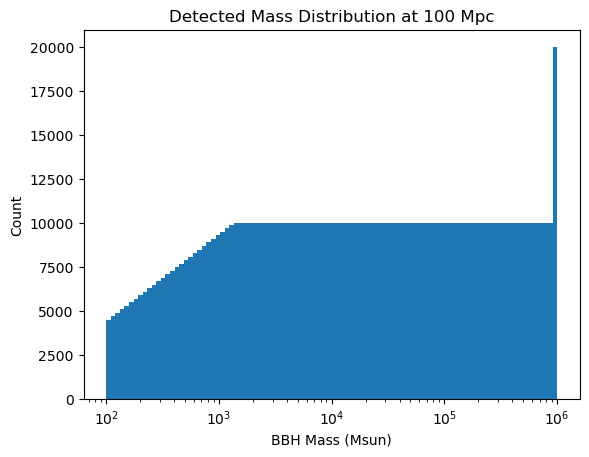

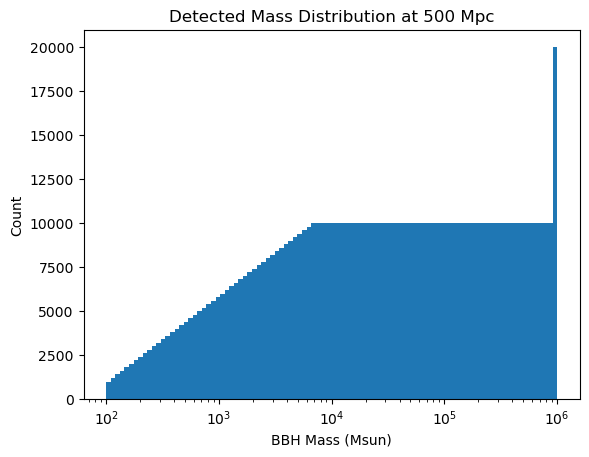

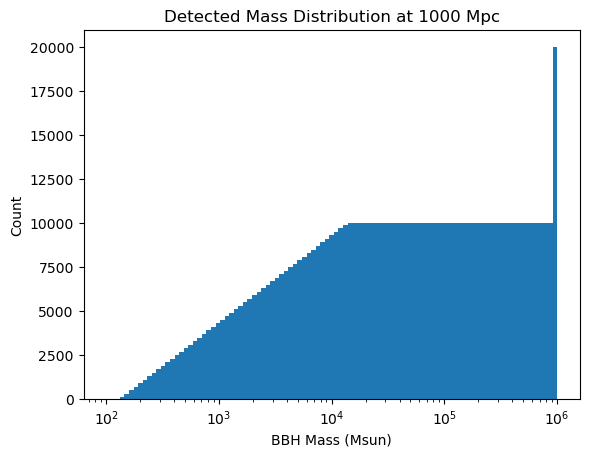

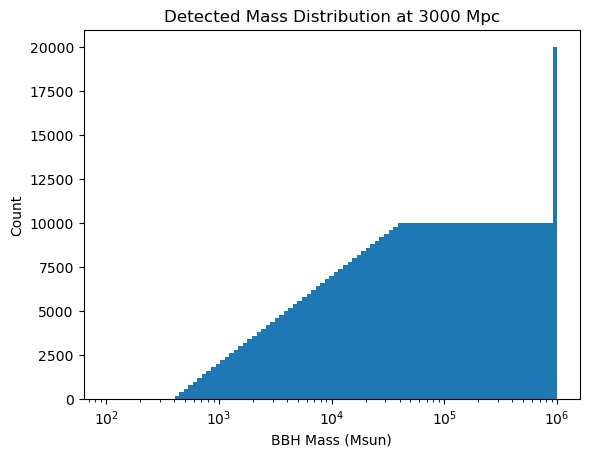

In [25]:
# Example: mass distribution at first distance
entry1 = detected_params_per_distance[0]
M_detected1 = [p["M"] for p in entry1["params"]]
entry2 = detected_params_per_distance[1]
M_detected2 = [p["M"] for p in entry2["params"]]
entry3 = detected_params_per_distance[2]
M_detected3 = [p["M"] for p in entry3["params"]]
entry4 = detected_params_per_distance[3]
M_detected4 = [p["M"] for p in entry4["params"]]

logbins = np.logspace(2,6,100)

plt.hist(M_detected1, bins=logbins)
plt.xscale('log')
plt.xlabel("BBH Mass (Msun)")
plt.ylabel("Count")
plt.title(f"Detected Mass Distribution at {entry1['distance_Mpc']} Mpc")
plt.show()

plt.hist(M_detected2, bins=logbins)
plt.xscale('log')
plt.xlabel("BBH Mass (Msun)")
plt.ylabel("Count")
plt.title(f"Detected Mass Distribution at {entry2['distance_Mpc']} Mpc")
plt.show()

plt.hist(M_detected3, bins=logbins)
plt.xscale('log')
plt.xlabel("BBH Mass (Msun)")
plt.ylabel("Count")
plt.title(f"Detected Mass Distribution at {entry3['distance_Mpc']} Mpc")
plt.show()

plt.hist(M_detected4, bins=logbins)
plt.xscale('log')
plt.xlabel("BBH Mass (Msun)")
plt.ylabel("Count")
plt.title(f"Detected Mass Distribution at {entry4['distance_Mpc']} Mpc")
plt.show()

# NEXT STEPS:

- Figure out expected time offset between jet detection and merger of IMBH binary (merger happens before jet, so detecting the merger with GW detectors lets us have enough time hopefully to point NewAthena in that direction). Check Fig 1 of Word doc proposal (Tagawa et al. 2023 Fig 19), they migth have an estimate there for this time.

- bilby will give us uncertainties on mass and distance estimations needed for Hubble constant calculation (check out Hubble constant measurements with GW events)

- 

 